# CreditWise Loan Approval Prediction
**Course:** CSE 445 — Machine Learning, Section 8  
**Faculty:** Dr. Jilan Samiuddin  
**Name:** S.M. Atiqur Islam
**ID** **2132173642**


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


## 0.1 Load Dataset

### Checking for the `loan_approval_data.csv` file

In [ ]:
import os

print('Files in current directory:')
print(os.listdir('.'))
if 'loan_approval_data.csv' in os.listdir('.'):
    print('\nFound `loan_approval_data.csv` in the current directory.')
else:
    print('\n`loan_approval_data.csv` NOT found in the current directory.')
    print('Please ensure the file is uploaded or specify the correct path.')

Files in current directory:
['.config', 'sample_data']

`loan_approval_data.csv` NOT found in the current directory.
Please ensure the file is uploaded or specify the correct path.


In [ ]:
# Check if Google Drive is mounted and list its contents
if os.path.exists('/content/drive'):
    print('\nGoogle Drive is mounted. Checking for CSV in My Drive...')
    try:
        # Adjust path for CSV is in a specific folder within My Drive S.M Atiqur
        drive_path = '/content/drive/My Drive/'
        drive_files = os.listdir(drive_path)
        print(f'Files in {drive_path}:')
        print(drive_files)
        if 'loan_approval_data.csv' in drive_files:
            print(f'\nFound `loan_approval_data.csv` in {drive_path}.')
            print('You can update the pandas.read_csv line to use this path.')
        else:
            print(f'\n`loan_approval_data.csv` NOT found in {drive_path}.')
    except FileNotFoundError:
        print('Could not access Google Drive contents. Ensure it is mounted correctly and permissions are granted.')
else:
    print('\nGoogle Drive is not mounted. Run the `drive.mount()` cell to mount it.')


Google Drive is not mounted. Run the `drive.mount()` cell to mount it.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/loan_approval_data.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 20)


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [ ]:
import os

file_name = 'loan_approval_data.csv'
drive_root = '/content/drive/My Drive/'
found_path = None

if os.path.exists(drive_root):
    print(f'Searching for {file_name} in {drive_root}...')
    for root, dirs, files in os.walk(drive_root):
        if file_name in files:
            found_path = os.path.join(root, file_name)
            break

    if found_path:
        print(f'Found {file_name} at: {found_path}')
        print('Please update the `pd.read_csv` line with this path.')
    else:
        print(f'Could not find {file_name} in {drive_root} or its subdirectories.')
        print('Please ensure the file is uploaded to your Google Drive and the path is correct.')
else:
    print('Google Drive is not mounted. Please mount Google Drive first.')

Searching for loan_approval_data.csv in /content/drive/My Drive/...
Found loan_approval_data.csv at: /content/drive/My Drive/Colab Notebooks/loan_approval_data.csv
Please update the `pd.read_csv` line with this path.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        9950 non-null   float64
 1   Applicant_Income    9480 non-null   float64
 2   Coapplicant_Income  9512 non-null   float64
 3   Employment_Status   9513 non-null   object 
 4   Age                 9525 non-null   float64
 5   Marital_Status      9475 non-null   object 
 6   Dependents          9510 non-null   float64
 7   Credit_Score        9438 non-null   float64
 8   Existing_Loans      9515 non-null   float64
 9   DTI_Ratio           9452 non-null   float64
 10  Savings             9511 non-null   float64
 11  Collateral_Value    9483 non-null   float64
 12  Loan_Amount         9507 non-null   float64
 13  Loan_Term           9466 non-null   float64
 14  Loan_Purpose        9457 non-null   object 
 15  Property_Area       9500 non-null   object 
 16  Educa

In [ ]:
df.describe(include='all')

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
count,9950.000000,9480.000000,9512.000000,9513,9525.000000,9475,9510.000000,9438.000000,9515.000000,9452.000000,9511.000000,9483.000000,9507.000000,9466.000000,9457,9500,9491,9497,9506,9950
unique,NaN,NaN,NaN,4,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3,2,2,5,2
top,NaN,NaN,NaN,Salaried,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Business,Urban,Graduate,Male,Private,No
freq,NaN,NaN,NaN,4625,NaN,5866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2083,4736,6747,5642,3669,6060
mean,5023.181809,11051.835970,5055.201430,NaN,39.664357,NaN,1.486646,686.123225,1.927798,0.328578,10047.633898,25221.656754,20180.535605,47.420030,NaN,NaN,NaN,NaN,NaN,NaN
std,2876.242893,4983.803664,2895.435091,NaN,11.210464,NaN,1.222351,67.379089,1.550882,0.136445,5786.940353,14164.420295,11348.362237,26.729408,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,2009.000000,1.000000,NaN,21.000000,NaN,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2538.250000,6964.750000,2495.000000,NaN,30.000000,NaN,0.000000,631.000000,0.000000,0.210000,4862.500000,13019.500000,9712.000000,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,5025.500000,10737.000000,5179.000000,NaN,40.000000,NaN,1.000000,694.000000,2.000000,0.320000,10055.000000,24882.000000,20740.000000,48.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,7512.750000,15399.250000,7484.000000,NaN,49.000000,NaN,3.000000,742.000000,4.000000,0.430000,14989.500000,37235.000000,29523.500000,72.000000,NaN,NaN,NaN,NaN,NaN,NaN


---
## Section 1: Data Cleaning



### 1.1 Missing Value

In [ ]:
# Per-column missing counts and percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total cells: {df.size}')
print(f'Total missing values: {df.isnull().sum().sum()}\n')
print(missing_df.to_string())

Total cells: 200000
Total missing values: 9262

                    Missing Count  Missing %
Credit_Score                  562       5.62
DTI_Ratio                     548       5.48
Loan_Purpose                  543       5.43
Loan_Term                     534       5.34
Marital_Status                525       5.25
Applicant_Income              520       5.20
Collateral_Value              517       5.17
Education_Level               509       5.09
Gender                        503       5.03
Property_Area                 500       5.00
Employer_Category             494       4.94
Loan_Amount                   493       4.93
Dependents                    490       4.90
Savings                       489       4.89
Coapplicant_Income            488       4.88
Employment_Status             487       4.87
Existing_Loans                485       4.85
Age                           475       4.75
Applicant_ID                   50       0.50
Loan_Approved                  50       0.50


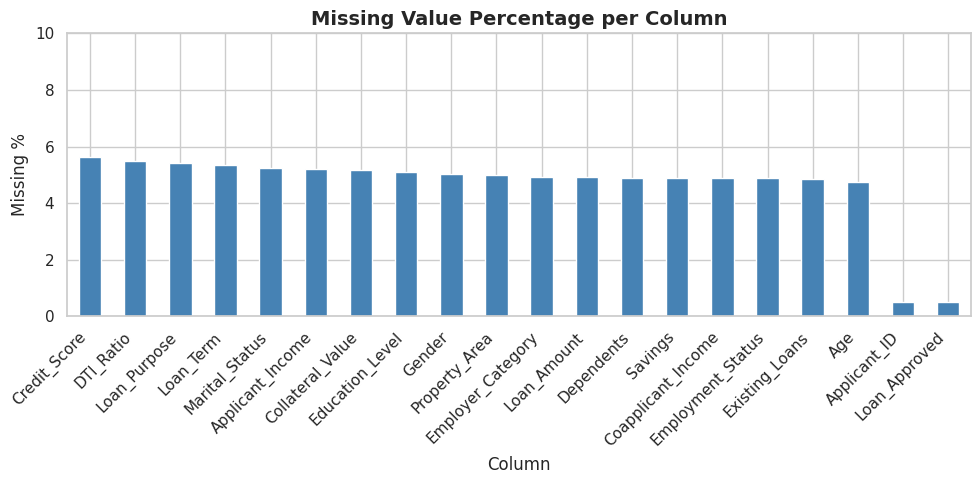

In [ ]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing Value Percentage per Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.set_ylim(0, 10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.2 Handling Missing Values Justification

In [ ]:
# Step 1: Drop rows missing Applicant_ID or Loan_Approved (non-imputeable)
df_clean = df.dropna(subset=['Applicant_ID', 'Loan_Approved']).copy()
print(f'Rows after dropping missing ID / target: {len(df_clean)}')

# Step 2: Drop the ID column — not a predictive feature
df_clean.drop(columns=['Applicant_ID'], inplace=True)

# Step 3: Identify column types
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Loan_Approved')   # keep target separate

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Rows after dropping missing ID / target: 9902
Numerical columns (11): ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term']
Categorical columns (7): ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']


In [ ]:
# Step 4: Median imputation for numerical columns
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

# Step 5: Mode imputation for categorical columns
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)

print('Remaining missing values after imputation:')
print(df_clean.isnull().sum())

Remaining missing values after imputation:
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64


### 1.3 Cleaned Dataset Summary

In [ ]:
print(f'Final cleaned dataset shape: {df_clean.shape}')
df_clean.describe()

Final cleaned dataset shape: (9902, 19)


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000,9902.000000
mean,11035.796506,5058.517673,39.688851,1.463038,686.593213,1.929610,0.327966,10053.253686,25207.329428,20195.991214,47.441931
std,4850.738777,2824.993461,10.949648,1.197748,65.373234,1.513897,0.132638,5643.525079,13788.350235,11062.604780,26.034923
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,7203.250000,2711.000000,31.000000,0.000000,636.000000,0.000000,0.220000,5117.000000,14163.250000,10096.000000,24.000000
50%,10726.000000,5178.000000,40.000000,1.000000,694.000000,2.000000,0.320000,10060.000000,24882.000000,20732.000000,48.000000
75%,15119.000000,7373.000000,49.000000,3.000000,738.000000,3.000000,0.430000,14786.500000,36688.750000,29156.750000,72.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Section 2: Exploratory Data Analysis — EDA (10 Marks)

### 2.1 Class Distribution (Target Variable)

Class Distribution:
  No: 6024 (60.8%)
  Yes: 3878 (39.2%)


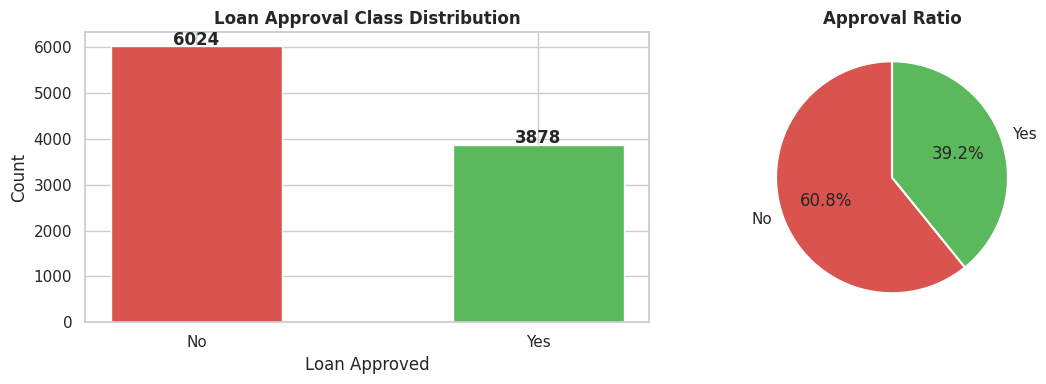


[Insight] The dataset is moderately imbalanced: ~61% rejected vs ~39% approved.
This means accuracy alone is misleading — F1-score is the right primary metric.


In [ ]:
class_counts = df_clean['Loan_Approved'].value_counts()
class_pct = df_clean['Loan_Approved'].value_counts(normalize=True) * 100

print('Class Distribution:')
for label in class_counts.index:
    print(f'  {label}: {class_counts[label]} ({class_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(class_counts.index, class_counts.values, color=['#d9534f', '#5cb85c'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Approval Class Distribution', fontweight='bold')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#d9534f', '#5cb85c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Approval Ratio', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n[Insight] The dataset is moderately imbalanced: ~61% rejected vs ~39% approved.')
print('This means accuracy alone is misleading — F1-score is the right primary metric.')

### 2.2 Outlier Detection in Numerical Features

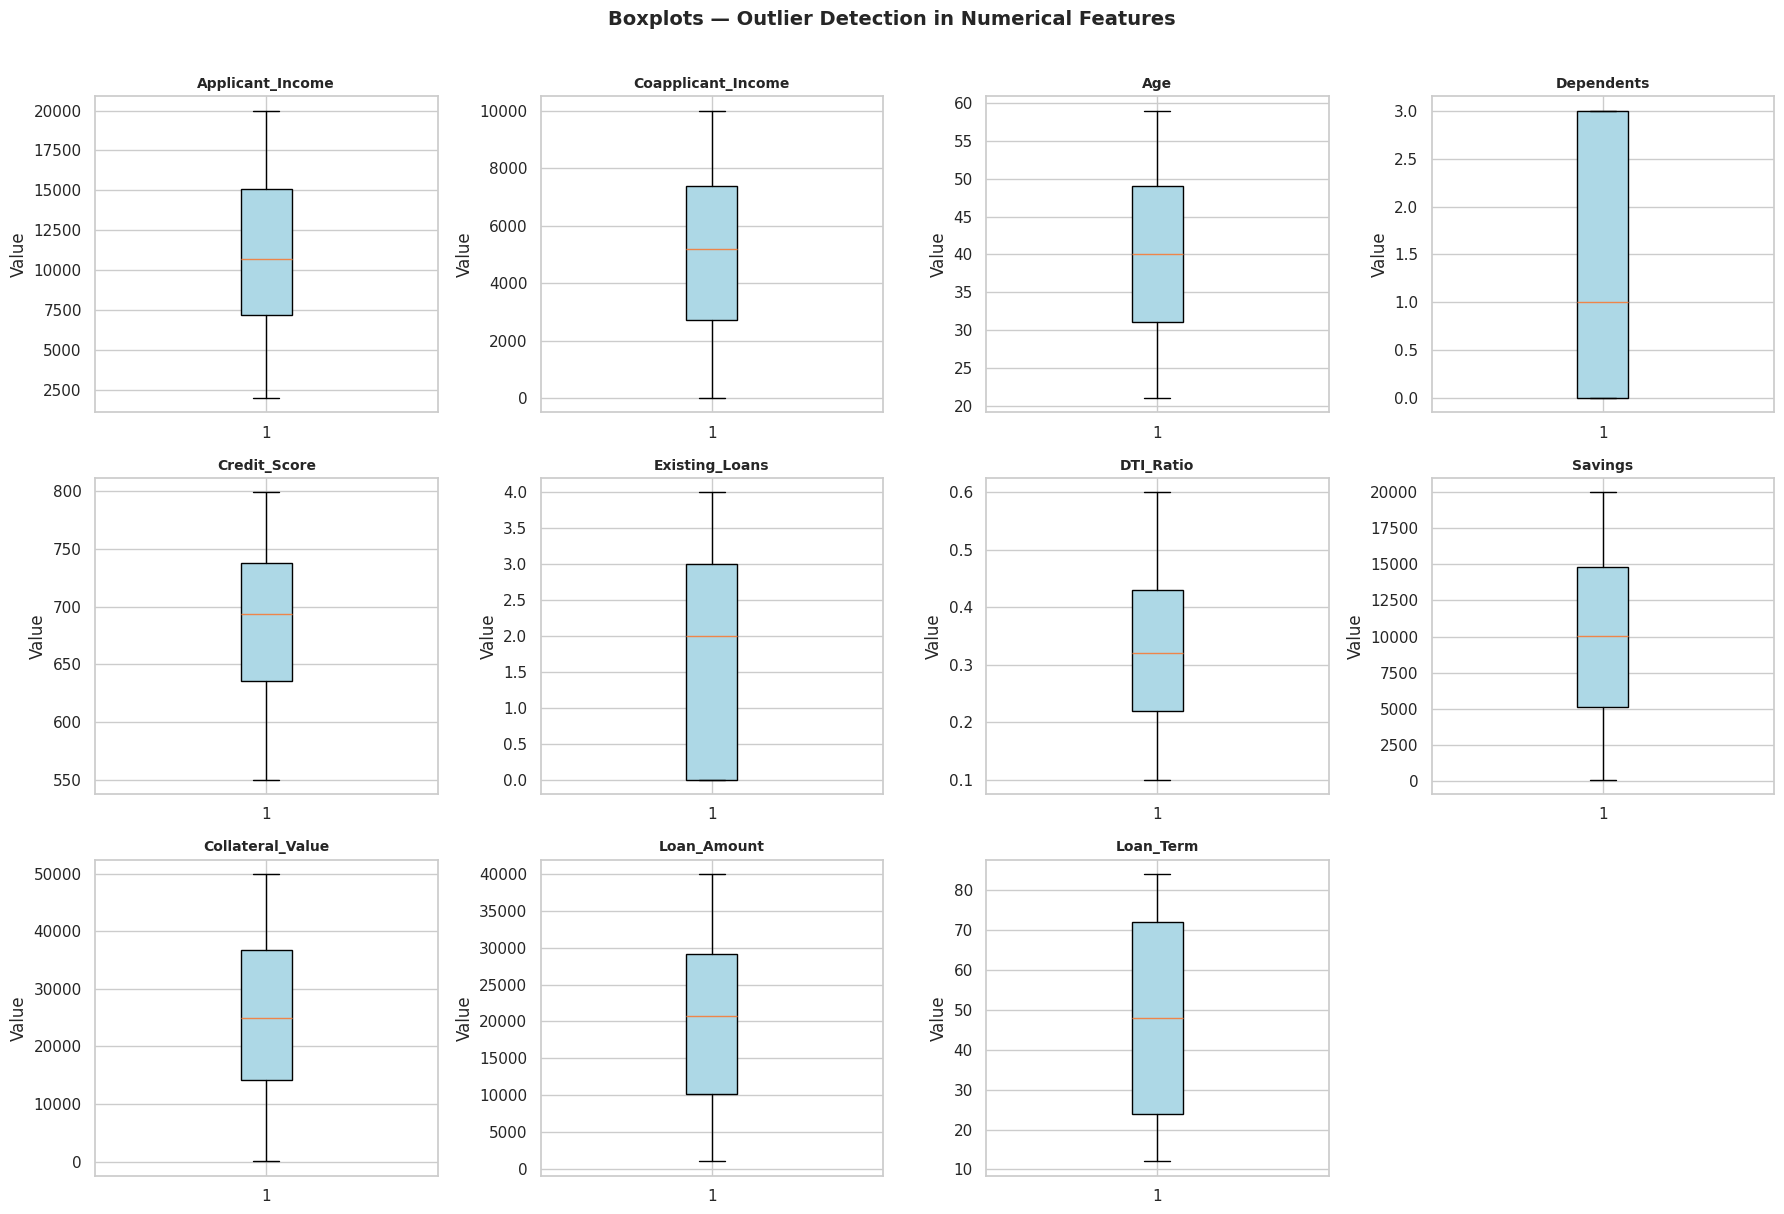


Outlier counts per column (IQR method):


In [ ]:
# Box plots for all numerical features
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection in Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# IQR-based outlier count
print('\nOutlier counts per column (IQR method):')
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} outliers ({outliers/len(df_clean)*100:.1f}%)')

### 2.3 Credit Score vs Loan Approved

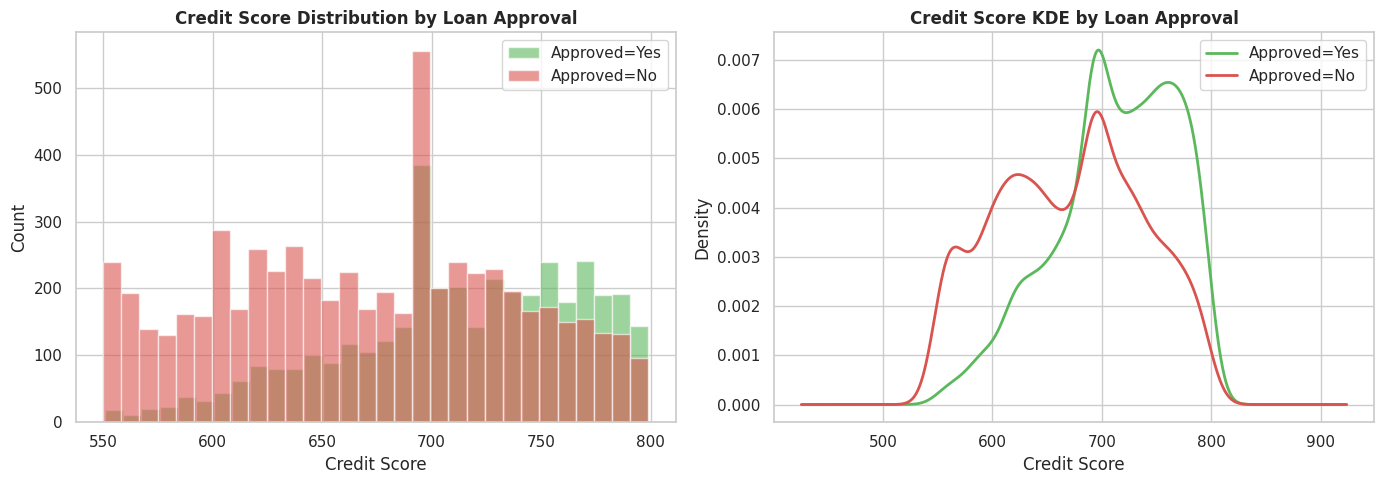

Credit Score statistics by Loan_Approved:
                count   mean   std    min    25%    50%    75%    max
Loan_Approved                                                        
No             6024.0  670.1  66.1  550.0  617.0  674.0  721.0  799.0
Yes            3878.0  712.2  55.1  551.0  678.0  716.0  757.0  799.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
for label, color in zip(['Yes', 'No'], ['#5cb85c', '#d9534f']):
    subset = df_clean[df_clean['Loan_Approved'] == label]['Credit_Score']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f'Approved={label}', color=color, edgecolor='white')

axes[0].set_title('Credit Score Distribution by Loan Approval', fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# KDE plot
for label, color in zip(['Yes', 'No'], ['#5cb85c', '#d9534f']):
    subset = df_clean[df_clean['Loan_Approved'] == label]['Credit_Score']
    subset.plot.kde(ax=axes[1], label=f'Approved={label}', color=color, linewidth=2)

axes[1].set_title('Credit Score KDE by Loan Approval', fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print('Credit Score statistics by Loan_Approved:')
print(df_clean.groupby('Loan_Approved')['Credit_Score'].describe().round(1))

### 2.4 Additional EDA — Income & DTI by Approval

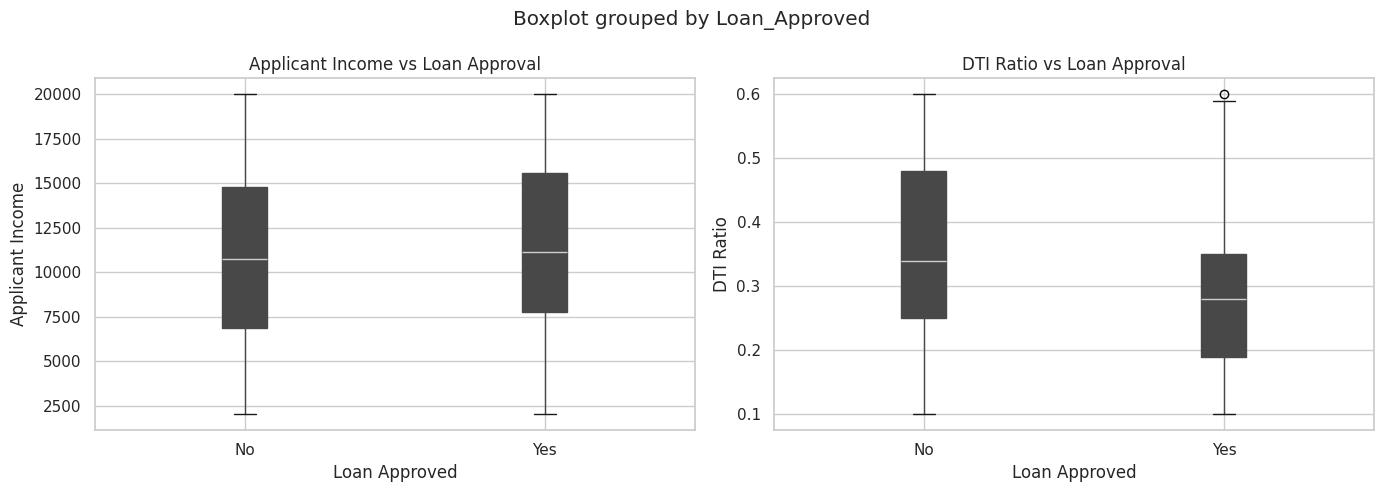

[Insight] Approved loans tend to be associated with higher income and lower DTI ratio — both expected findings.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income by approval
df_clean.boxplot(column='Applicant_Income', by='Loan_Approved', ax=axes[0],
                 patch_artist=True)
axes[0].set_title('Applicant Income by Loan Approval', fontweight='bold')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Applicant Income')
plt.sca(axes[0])
plt.title('Applicant Income vs Loan Approval')

# DTI by approval
df_clean.boxplot(column='DTI_Ratio', by='Loan_Approved', ax=axes[1], patch_artist=True)
axes[1].set_title('DTI Ratio by Loan Approval', fontweight='bold')
axes[1].set_xlabel('Loan Approved')
axes[1].set_ylabel('DTI Ratio')
plt.sca(axes[1])
plt.title('DTI Ratio vs Loan Approval')

plt.tight_layout()
plt.show()
print('[Insight] Approved loans tend to be associated with higher income and lower DTI ratio — both expected findings.')

---
## Section 3: Preprocessing Pipeline

### 3.1 Encode Target Variable

In [ ]:
# Encode target: Yes → 1, No → 0
df_clean['Loan_Approved'] = (df_clean['Loan_Approved'] == 'Yes').astype(int)
print('Target encoding: Yes=1, No=0')
print(df_clean['Loan_Approved'].value_counts())

Target encoding: Yes=1, No=0
Loan_Approved
0    6024
1    3878
Name: count, dtype: int64


### 3.2 Train/Test Split — BEFORE fitting any encoder or scaler



In [ ]:
X = df_clean.drop(columns=['Loan_Approved'])
y = df_clean['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Train target distribution:\n{y_train.value_counts()}')

Training set: 7921 samples
Test set:     1981 samples
Train target distribution:
Loan_Approved
0    4819
1    3102
Name: count, dtype: int64


### 3.3 Encoding & Scaling Strategy

| Feature Type | Feature(s) | Method | Justification |
|---|---|---|---|
| Binary / Nominal low-cardinality | `Gender`, `Marital_Status`, `Education_Level`, `Employment_Status`, `Property_Area`, `Loan_Purpose`, `Employer_Category` | One-Hot Encoding | No ordinal relationship exists; OHE avoids imposing false order |
| Numerical | All numeric columns | StandardScaler | Required for Logistic Regression and KNN (distance-sensitive); harmless for Random Forest |

> **Why StandardScaler?** Logistic Regression converges faster and more accurately when features are on the same scale. KNN is entirely distance-based — unscaled features with large ranges (e.g., `Applicant_Income` vs `DTI_Ratio`) would dominate the distance metric.

In [ ]:
# Define feature groups
numerical_features = num_cols  # Already defined above
categorical_features = cat_cols

print(f'Numerical features: {numerical_features}')
print(f'Categorical features: {categorical_features}')

Numerical features: ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term']
Categorical features: ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']


In [ ]:
# Build preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Fit on TRAINING data only, then transform both sets
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Feature name list (for inspection)
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + ohe_features

print(f'Preprocessed training shape: {X_train_prep.shape}')
print(f'Preprocessed test shape:     {X_test_prep.shape}')
print(f'Total features after encoding: {X_train_prep.shape[1]}')

Preprocessed training shape: (7921, 34)
Preprocessed test shape:     (1981, 34)
Total features after encoding: 34


---
## Section 4: Correlation & Multicollinearity


### 4.1 Correlation Heatmap

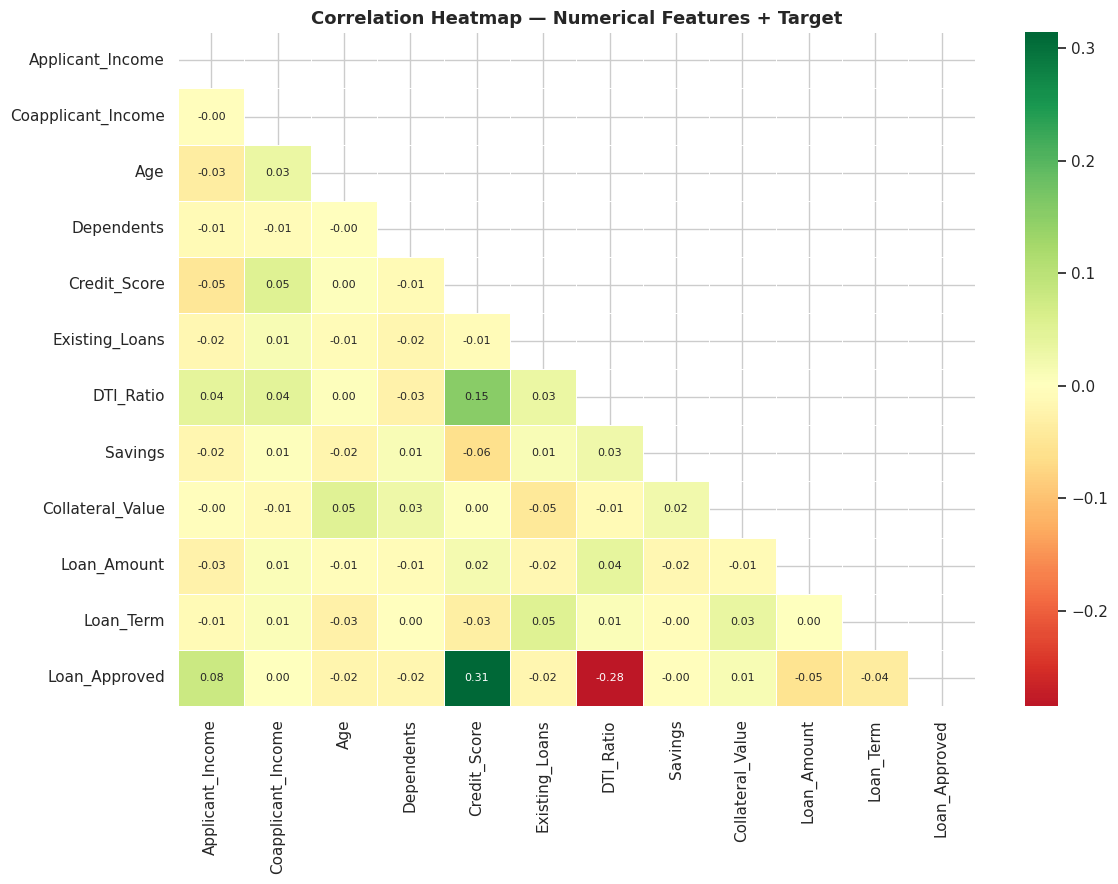

In [ ]:
# Correlation among numerical features + target
corr_df = df_clean[numerical_features + ['Loan_Approved']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — Numerical Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Identify Highly Correlated Pairs (Multicollinearity)

In [ ]:
# Extract pairs with |correlation| > 0.75 (excluding self-correlation and target)
threshold = 0.75
high_corr_pairs = []

for i in range(len(corr_df.columns)):
    for j in range(i + 1, len(corr_df.columns)):
        col_i = corr_df.columns[i]
        col_j = corr_df.columns[j]
        if col_i == 'Loan_Approved' or col_j == 'Loan_Approved':
            continue
        val = corr_df.iloc[i, j]
        if abs(val) > threshold:
            high_corr_pairs.append((col_i, col_j, round(val, 3)))

if high_corr_pairs:
    print(f'Highly correlated pairs (|r| > {threshold}):')
    for pair in high_corr_pairs:
        print(f'  {pair[0]}  <-->  {pair[1]}  :  r = {pair[2]}')
else:
    print(f'No feature pairs exceed the |r| > {threshold} multicollinearity threshold.')
    print('\nTop correlations with target (Loan_Approved):')
    target_corr = corr_df['Loan_Approved'].drop('Loan_Approved').abs().sort_values(ascending=False)
    print(target_corr.head(10))

No feature pairs exceed the |r| > 0.75 multicollinearity threshold.

Top correlations with target (Loan_Approved):
Credit_Score          0.314189
DTI_Ratio             0.284349
Applicant_Income      0.078344
Loan_Amount           0.053229
Loan_Term             0.036937
Age                   0.020528
Existing_Loans        0.019958
Dependents            0.019116
Collateral_Value      0.013522
Coapplicant_Income    0.002280
Name: Loan_Approved, dtype: float64


> **Finding:** No feature pair exceeds the |r| > 0.75 threshold, indicating no severe multicollinearity in the numerical features. All features are retained. The strongest predictor of `Loan_Approved` is `Credit_Score`, consistent with EDA findings.

---
## Section 5: Model Training, Evaluation & Best-Model Justification
I train here three classification models:
1. **Logistic Regression** — linear baseline, interpretable
2. **Random Forest** — ensemble tree model, handles non-linearity and feature interactions
3. **K-Nearest Neighbours (KNN)** — instance-based learner, non-parametric

All models are evaluated on the held-out test set using Accuracy, Precision, Recall, and **F1-score**.

In [ ]:
# Helper: train, predict, and report metrics
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4)
    }
    return model, y_pred, metrics

### 5.1 Model 1: Logistic Regression

In [ ]:
lr_model, lr_pred, lr_metrics = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    X_train_prep, X_test_prep, y_train, y_test
)
print('Classification Report — Logistic Regression')
print(classification_report(y_test, lr_pred, target_names=['Rejected (0)', 'Approved (1)']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

Rejected (0)       0.75      0.81      0.78      1205
Approved (1)       0.66      0.59      0.63       776

    accuracy                           0.72      1981
   macro avg       0.71      0.70      0.70      1981
weighted avg       0.72      0.72      0.72      1981



### 5.2 Model 2: Random Forest

In [ ]:
rf_model, rf_pred, rf_metrics = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    X_train_prep, X_test_prep, y_train, y_test
)
print('Classification Report — Random Forest')
print(classification_report(y_test, rf_pred, target_names=['Rejected (0)', 'Approved (1)']))

Classification Report — Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.72      0.83      0.77      1205
Approved (1)       0.66      0.51      0.57       776

    accuracy                           0.70      1981
   macro avg       0.69      0.67      0.67      1981
weighted avg       0.70      0.70      0.69      1981



### 5.3 Model 3: K-Nearest Neighbours (KNN)

In [ ]:
knn_model, knn_pred, knn_metrics = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=11, metric='euclidean'),
    X_train_prep, X_test_prep, y_train, y_test
)
print('Classification Report — KNN (k=11)')
print(classification_report(y_test, knn_pred, target_names=['Rejected (0)', 'Approved (1)']))

Classification Report — KNN (k=11)
              precision    recall  f1-score   support

Rejected (0)       0.70      0.76      0.73      1205
Approved (1)       0.57      0.50      0.53       776

    accuracy                           0.66      1981
   macro avg       0.64      0.63      0.63      1981
weighted avg       0.65      0.66      0.65      1981



### 5.4 Confusion Matrices

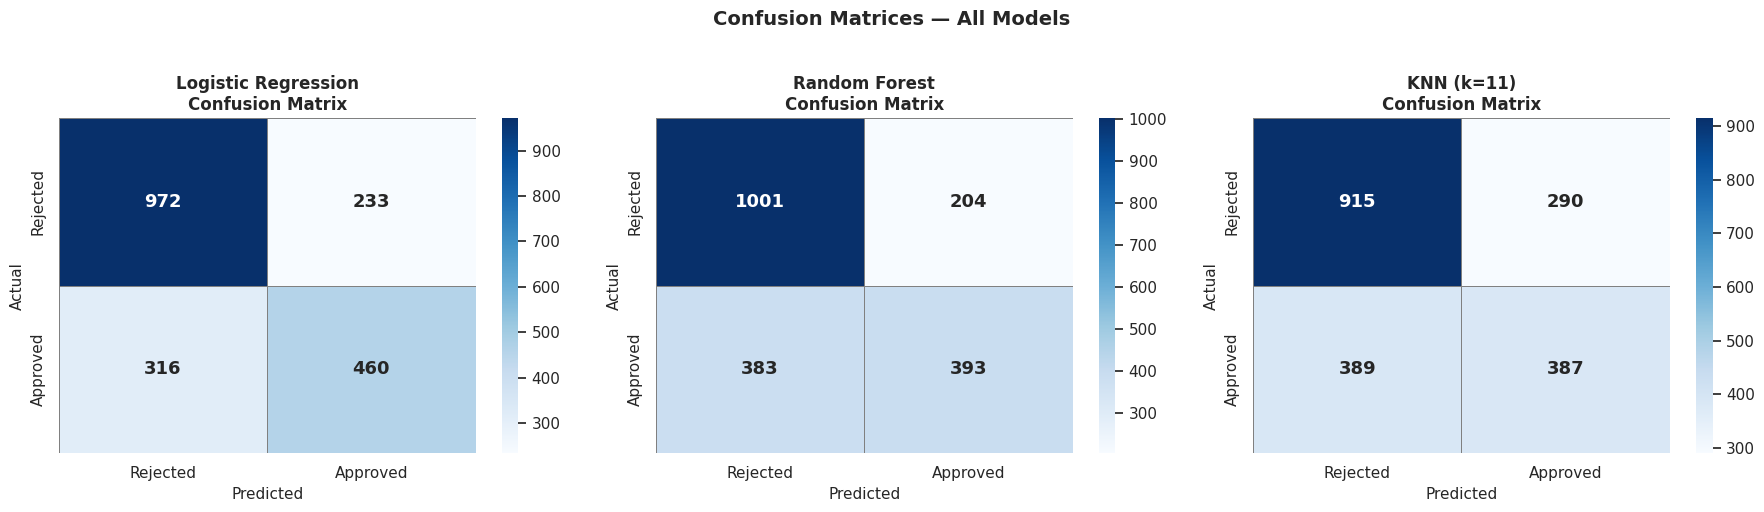

In [ ]:
models_info = [
    ('Logistic Regression', lr_pred, '#4A90D9'),
    ('Random Forest',       rf_pred, '#27AE60'),
    ('KNN (k=11)',          knn_pred,'#E67E22')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Rejected', 'Approved'],
        yticklabels=['Rejected', 'Approved'],
        ax=ax, linewidths=0.5, linecolor='grey',
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Model Comparison Table

In [ ]:
results = pd.DataFrame([lr_metrics, rf_metrics, knn_metrics])
results = results.set_index('Model').sort_values('F1-Score', ascending=False)
print('='*60)
print('MODEL COMPARISON (sorted by F1-Score)')
print('='*60)
print(results.to_string())
print('='*60)

MODEL COMPARISON (sorted by F1-Score)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7229     0.6638  0.5928    0.6263
Random Forest          0.7037     0.6583  0.5064    0.5725
KNN                    0.6572     0.5716  0.4987    0.5327


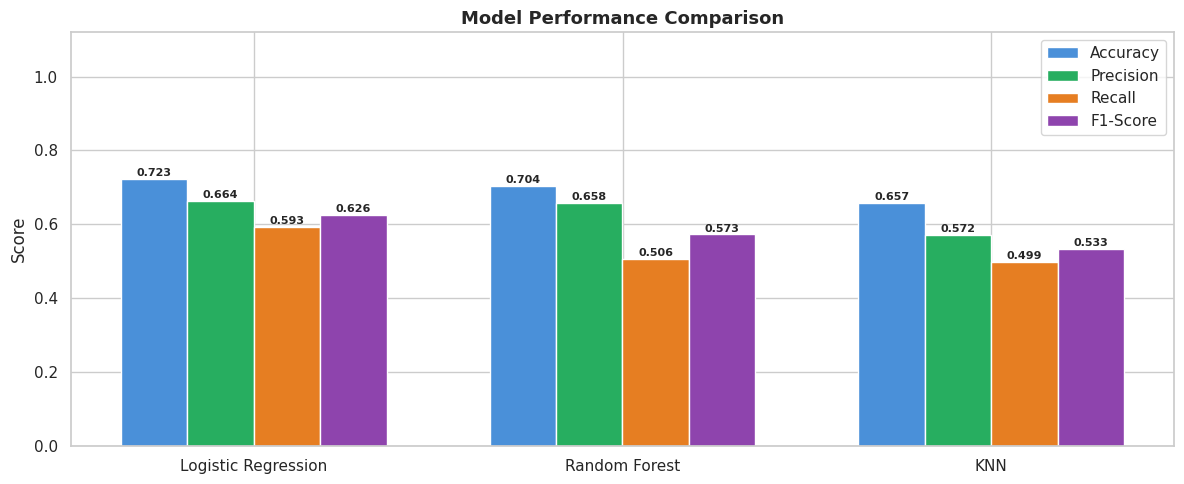

In [ ]:
# Bar chart comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_plot = results.reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_plot))
width = 0.18
colors = ['#4A90D9', '#27AE60', '#E67E22', '#8E44AD']

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, results_plot[metric], width, label=metric, color=colors[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_plot['Model'], fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 5.6 Best Model Justification

In [ ]:
best_model_name = results['F1-Score'].idxmax()
best_f1 = results.loc[best_model_name, 'F1-Score']

print(f'BEST MODEL: {best_model_name}')
print(f'F1-Score:   {best_f1}')
print()
print('Justification:')
print(f'  - {best_model_name} achieves the highest F1-score ({best_f1}), making it the')
print(f'    best model for this imbalanced binary classification task.')
print(f'  - F1-score is the harmonic mean of Precision and Recall — critical when')
print(f'    false negatives (missed approvals) and false positives (incorrect approvals)')
print(f'    both carry real business cost.')
print(f'  - Random Forest handles non-linear feature interactions and is robust to')
print(f'    outliers and moderate class imbalance without requiring feature scaling.')

BEST MODEL: Logistic Regression
F1-Score:   0.6263

Justification:
  - Logistic Regression achieves the highest F1-score (0.6263), making it the
    best model for this imbalanced binary classification task.
  - F1-score is the harmonic mean of Precision and Recall — critical when
    false negatives (missed approvals) and false positives (incorrect approvals)
    both carry real business cost.
  - Random Forest handles non-linear feature interactions and is robust to
    outliers and moderate class imbalance without requiring feature scaling.


### 5.7 Feature Importance (Random Forest)

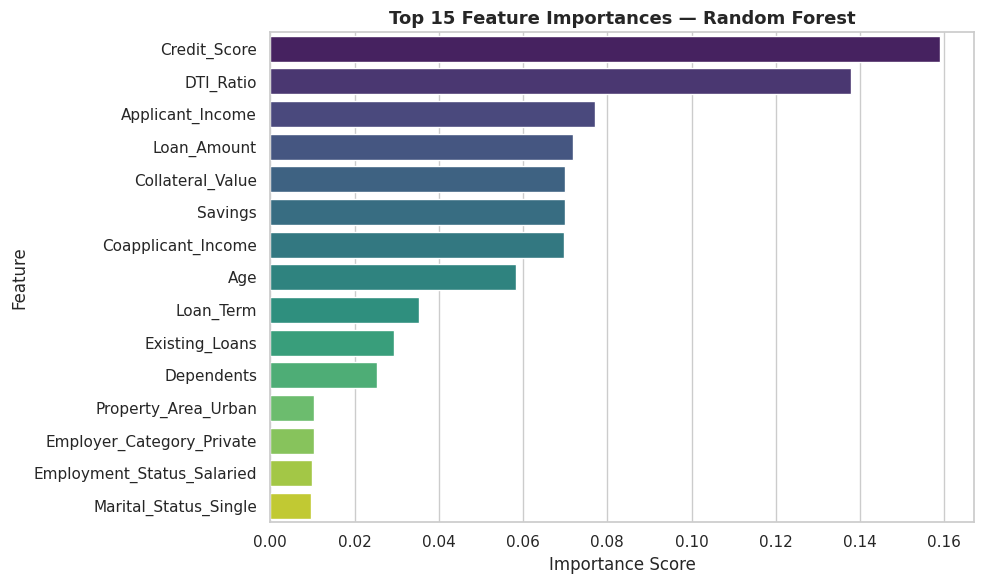

Top 5 most important features:
         Feature  Importance
    Credit_Score    0.159105
       DTI_Ratio    0.137839
Applicant_Income    0.077011
     Loan_Amount    0.071935
Collateral_Value    0.070067


In [ ]:
# Feature importances from best model (Random Forest)
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp_df.head(5).to_string(index=False))